Performs logistic regression on `mcts2.txt`, a CSV generated by `bin/mcts2.rs` with the following:

- `black_rollouts` number of MCTS rollouts performed by the black player (goes first)
- `white_rollouts` number of MCTS rollouts performed by the white player (goes second)
- `result` 1 or 0 depending on whether black won

400 matchups were generated randomly with $121^X$ rollouts per player, where $X$ is selected uniformly from $2.0$ to $3.5$. $X$ is expected to be roughly proportional to the depth of the tree explored by that player.

In [1]:
import csv
import math
import numpy as np

xs = []
ys = []
with open('mcts2.txt') as f:
    reader = csv.DictReader(f)
    for row in reader:
        black_rollouts = float(row['black_rollouts'])
        white_rollouts = float(row['white_rollouts'])
        xs.append(math.log10(black_rollouts / white_rollouts))
        ys.append(float(row['result']))

xs = np.array(xs)
ys = np.array(ys)

np.stack([xs, ys]).shape

(2, 400)

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xs.reshape((-1, 1)), ys)
model.n_iter_

array([7], dtype=int32)

b0 = 0.3866330842834316
b1 = 1.949241313263004


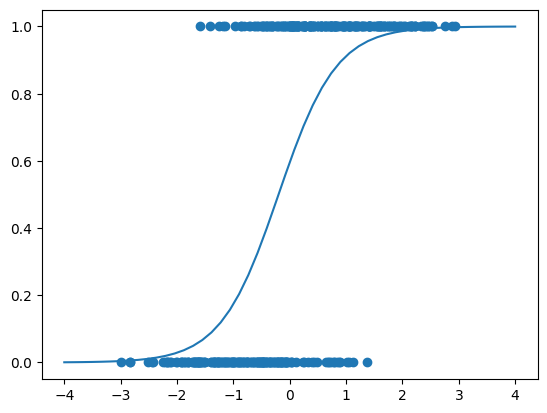

In [3]:
import matplotlib.pyplot as plt

b0 = model.intercept_[0]
b1 = model.coef_[0,0]
print('b0 =', b0)
print('b1 =', b1)

def predict(x):
    return 1. / (1. + np.exp(-(b0 + b1 * x)))

x = np.linspace(-4, 4)
y = predict(x)
plt.plot(x, y)
plt.scatter(xs, ys)
plt.show()

In [4]:
x = np.arange(-2, 2, 0.5)
y = predict(x)
print(np.stack([x, y]).T)

[[-2.          0.02897695]
 [-1.5         0.07328916]
 [-1.          0.1732727 ]
 [-0.5         0.35709673]
 [ 0.          0.59547192]
 [ 0.5         0.79596339]
 [ 1.          0.91180488]
 [ 1.5         0.9647871 ]]


In [5]:
def to_mcts(x):
    return np.pow(10.0, x)
def to_elo(x):
    return 400.0 * (b0 + b1 * x)

x = np.arange(-1, 2.01, 0.25)
y = to_elo(x)+1500
x = to_mcts(x)*100000
print(f'{'ROLLOUTS':>10} {'ELO':>10}')
for x, y in zip(x, y):
    print(f'{x:10.0f} {y:10.0f}')

  ROLLOUTS        ELO
     10000        875
     17783       1070
     31623       1265
     56234       1460
    100000       1655
    177828       1850
    316228       2045
    562341       2239
   1000000       2434
   1778279       2629
   3162278       2824
   5623413       3019
  10000000       3214


The above table shows the effective Elo rating of the black player when using the given number of rollouts and playing against a white player with elo 1500 and using 100,000 rollouts.